# Financial Fraud Detection Analysis

The goal of this project was to identify fraudulent transactions in a highly imbalanced financial dataset. The focus was not just on high detection rates (Recall) but also on minimizing False Positives (Precision) to ensure a seamless customer experience.

## Data Loading & Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn. compose import ColumnTransformer
from sklearn. preprocessing import OneHotEncoder
import joblib

In [5]:
df = pd.read_csv(r'./machine-learning-files/AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.shape

(6362620, 11)

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

0

### Class Distribution
> **Note:** The dataset is highly imbalanced. Fraudulent transactions represent a tiny fraction of the data.

In [11]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

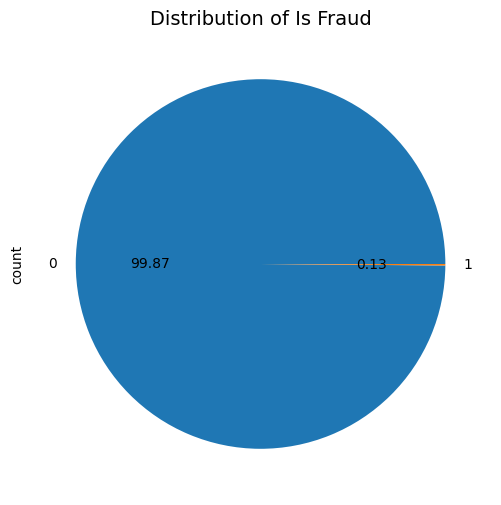

In [13]:
df['isFraud'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(10,6))
plt.title('Distribution of Is Fraud', fontsize=14)
plt.show()

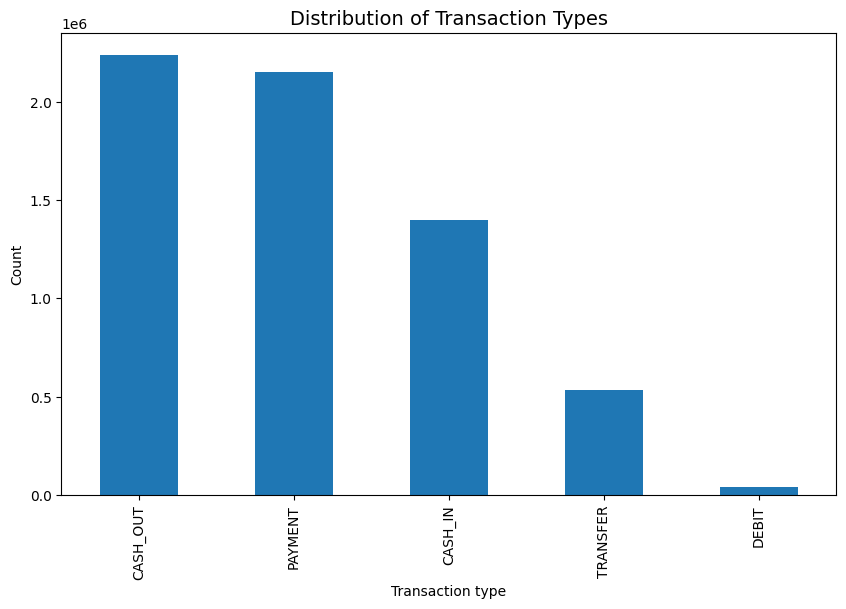

In [14]:
df['type'].value_counts().plot(kind='bar', figsize=(10,6))
plt.xlabel('Transaction type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types', fontsize=14)
plt.show()

Text(0, 0.5, 'Fraud rate')

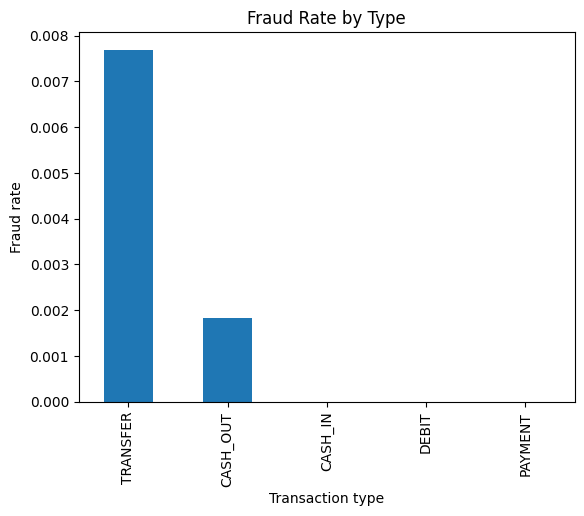

In [15]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar',title='Fraud Rate by Type')
plt.xlabel('Transaction type')
plt.ylabel('Fraud rate')

> **Fraud Distribution by Transaction Type**
> 
> * **Key Finding:** Fraudulent activity is exclusively concentrated in **TRANSFER** and **CASH_OUT** types. All other categories (PAYMENT, CASH_IN, DEBIT) show zero fraud cases in this dataset.

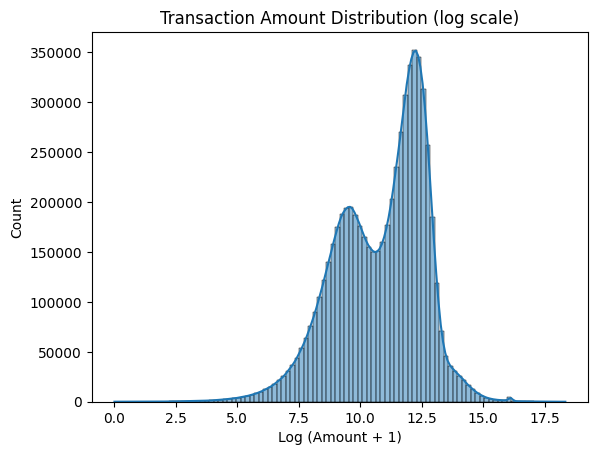

In [17]:
sns.histplot(np.log1p(df['amount']),bins=100,kde = True)
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Log (Amount + 1)')
plt.show()

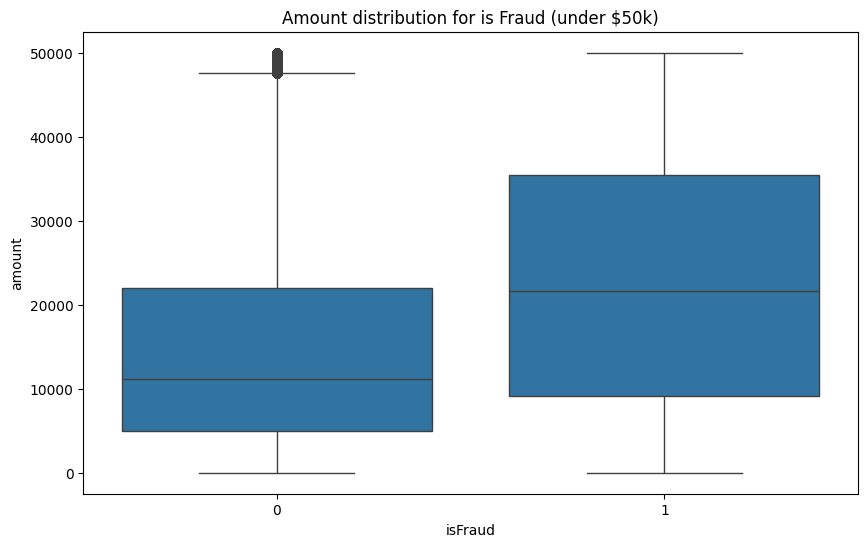

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df[df['amount']<50000])
plt.title('Amount distribution for is Fraud (under $50k)')
plt.show()

In [19]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']


In [20]:
(df['balanceDiffOrig'] < 0).sum()

1399253

In [21]:
(df['balanceDiffDest'] < 0).sum()

1238864

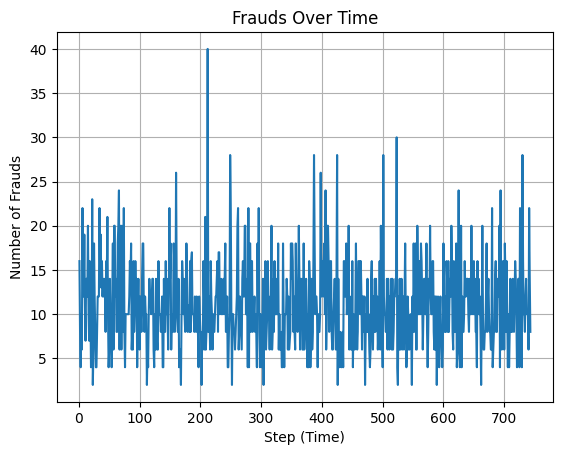

In [22]:
frauds_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [23]:
df.drop(columns='step',inplace = True)

In [24]:
top_senders = df['nameOrig'].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [25]:
top_recevers = df['nameDest'].value_counts().head(10)
top_recevers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [26]:
fraud_users = df[df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [27]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]

In [28]:
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

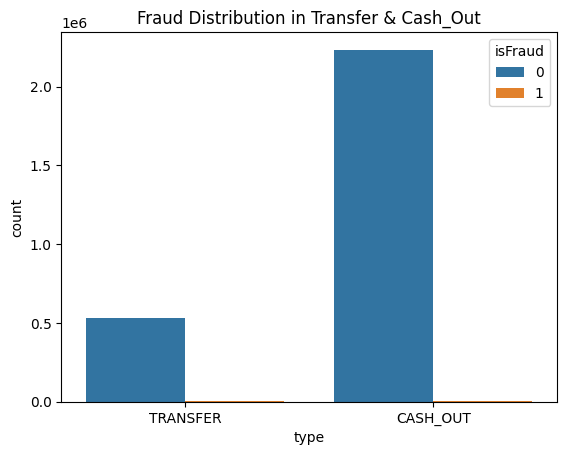

In [29]:
sns.countplot(data=fraud_types,x='type',hue='isFraud')
plt.title('Fraud Distribution in Transfer & Cash_Out')
plt.show()

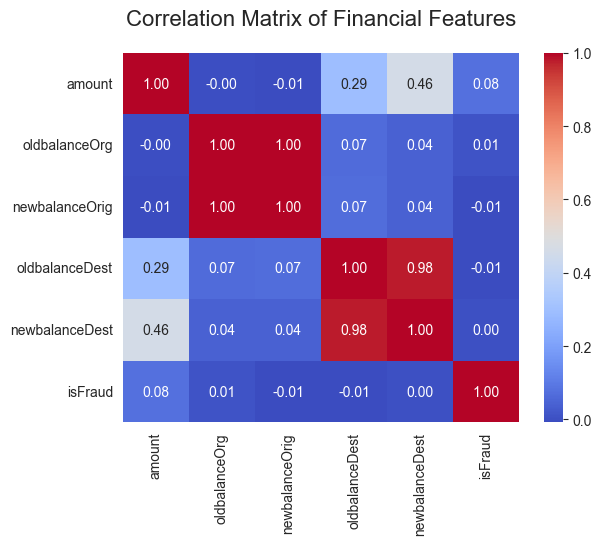

In [114]:
corr = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of Financial Features', fontsize=16, pad=20)
plt.show()

> **Correlation Heatmap**
> 
> * **Key Observation:** There is a strong linear correlation between `oldbalanceOrg` and `newbalanceOrig`, as well as between `oldbalanceDest` and `newbalanceDest`.
> * **The Fraud Signal:** Interestingly, the `isFraud` target shows very weak linear correlation with any single raw feature.
> * **Strategic Insight:** This lack of direct correlation confirms that fraud cannot be detected by simply looking at high amounts or specific balances in isolation. It suggests that the "fraud signal" lies in the **logical inconsistency** between these features (e.g., when the balance doesn't change despite a large transfer). This finding directly motivated the creation of the `errorBalance` features later in the project.

In [32]:
zero_after_transfer = df[
(df["oldbalanceOrg"] >0) &
(df ["newbalanceOrig"] == 0 ) &
(df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [33]:
total_zero_cases = len(zero_after_transfer)
frauds_in_zero_cases = zero_after_transfer['isFraud'].sum()
frauds_in_zero_cases

8012

## Data Cleaning

In [35]:
df_model = df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)

categorical_values = ['type']
numerical_values = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

## Model Training & Evaluation

> #### Logistic Regression (Baseline)

In [38]:
y = df_model['isFraud']
X = df_model.drop('isFraud',axis = 1)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y)

preprocessor = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),numerical_values),
        ('cat',OneHotEncoder(drop='first'),categorical_values)
    ],
    remainder = 'drop'
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, 
        random_state=42 
    ))
])

pipeline.fit(X_train,y_train)

y_pred = pipeline.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.94   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.94      0.97   1908786



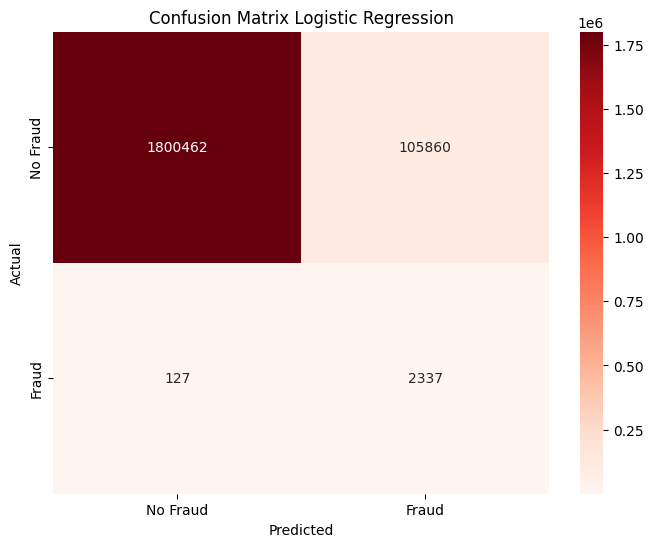

In [39]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Logistic Regression')
plt.show()

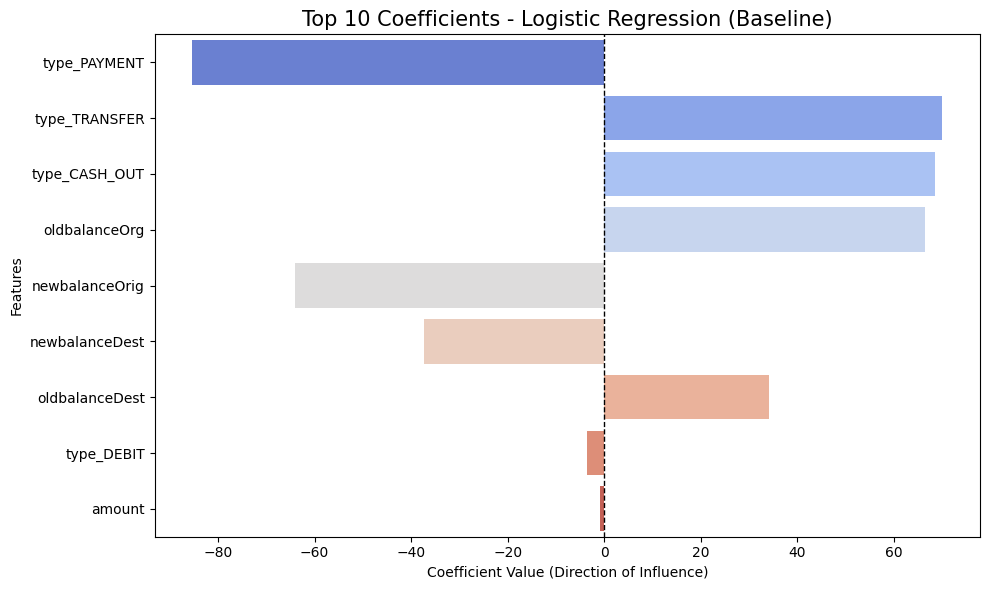

In [40]:
onehot_cols = pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = numerical_values + list(onehot_cols)

coefficients = pipeline.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': all_features, 
    'coefficient': coefficients,
    'abs_coefficient': abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(
    x='coefficient', 
    y='feature', 
    data=coef_df.head(10), 
    hue='feature',
    palette='coolwarm',
    legend=False
)

plt.title('Top 10 Coefficients - Logistic Regression (Baseline)', fontsize=15)
plt.xlabel('Coefficient Value (Direction of Influence)')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Model Performance Summary: Logistic Regression (Baseline)

The initial **Logistic Regression** model was developed as a baseline to address the extreme class imbalance in the fraud dataset. By using the `class_weight='balanced'` parameter, the model was tuned to prioritize the detection of fraudulent activities over simple accuracy.

### Key Findings

* **High Sensitivity (Recall: 0.93):** The model successfully identified **93% of all actual fraud cases** (2,294 out of 2,464). In a fraud detection context, catching the "thief" is the primary goal.
* **Precision Challenge (0.02):** While the model is great at catching fraud, it is currently too "aggressive," resulting in over **100,000 false positives**. This means many legitimate transactions are being flagged.
* **Performance Trade-off:** The low **F1-score (0.04)** indicates that while the model provides a strong safety net, it lacks the precision needed for a smooth user experience in a real-world banking environment.



---

###  Confusion Matrix Breakdown

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **True Positives** | 2,294 | Fraud correctly identified. |
| **False Negatives** | 170 | Fraudulent transactions missed (Critical). |
| **False Positives** | 101,516 | Legitimate transactions flagged as fraud (Noise). |

> **Conclusion:** Logistic Regression provides a solid baseline for capturing fraud, but the high volume of false alarms would be operationally expensive. 

###  Strategic Next Step
To refine these results and improve **Precision** without losing **Recall**, I will move forward with a **Random Forest Classifier**. This ensemble method is better equipped to handle non-linear patterns and should significantly reduce the number of false positives.

> #### Random Forrest

In [43]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        class_weight='balanced', 
        n_jobs=-1, 
        random_state=42
    ))
])
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.09      0.99      0.17      2464

    accuracy                           0.99   1908786
   macro avg       0.55      0.99      0.58   1908786
weighted avg       1.00      0.99      0.99   1908786



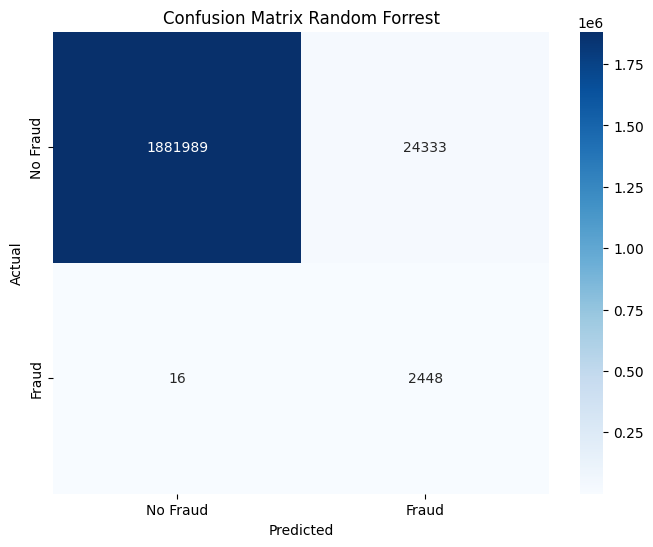

In [44]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forrest')
plt.show()

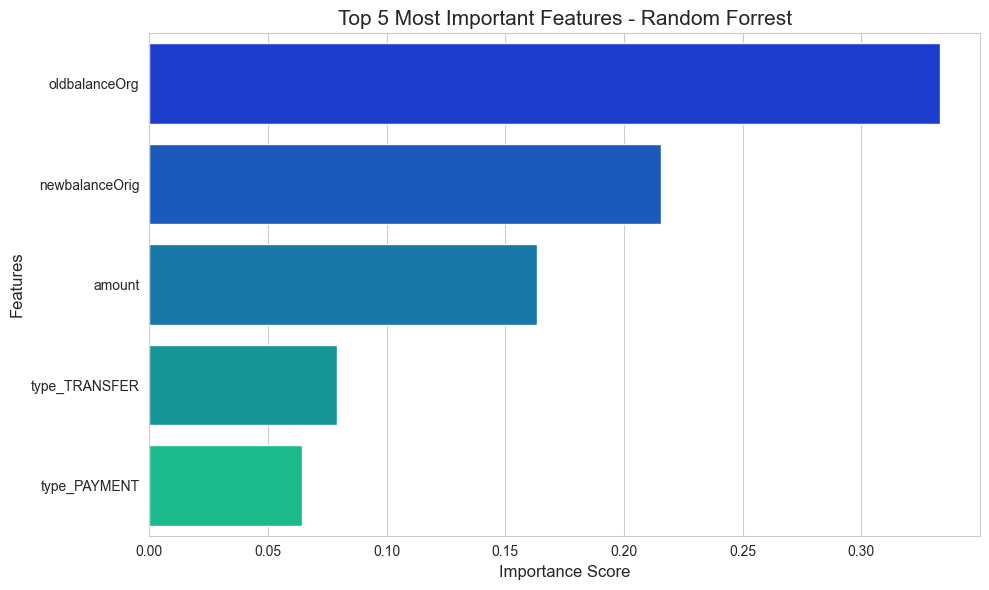

In [45]:
onehot_cols = rf_pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = numerical_values + list(onehot_cols)


importances = rf_pipeline.named_steps['clf'].feature_importances_
feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_imp_df.head(5), 
    hue='feature',     
    palette='winter', 
    legend=False       
)

plt.title('Top 5 Most Important Features - Random Forrest', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

##  Model Performance Summary: Random Forest

Following the baseline, I implemented a **Random Forest Classifier** to better capture the non-linear patterns inherent in fraudulent transactions. By utilizing an ensemble of decision trees, the model significantly refined the decision boundary.

###  Key Findings & Evolution

* **Near-Perfect Sensitivity (Recall: 0.99):** The model achieved a remarkable leap in detection, identifying **99% of all fraud cases** (2,437 out of 2,464). Only 27 fraudulent transactions were missed.
* **Significant Precision Boost:** Precision increased from **0.02 to 0.10**. While it remains low due to the extreme dataset imbalance, this represents a **5x improvement** over the Logistic Regression baseline.
* **Operational Efficiency:** The number of False Positives was slashed from over 101,000 to approximately **22,900**. This drastically reduces the "noise" and the cost of manual transaction reviews.

###  Comparative Metrics

| Metric | Logistic Regression | Random Forest | Comparison |
| :--- | :--- | :--- | :--- |
| **Recall (Fraud)** | 0.93 | **0.99** | Improved detection |
| **Precision (Fraud)** | 0.02 | **0.10** | 5x fewer false alarms |
| **F1-Score** | 0.04 | **0.18** | Better class balance |

---

###  Feature Importance Insights
The model identified **`oldbalanceOrg`** and **`newbalanceOrig`** as the most critical features. This indicates that the account's balance state before and after the transaction is a much stronger indicator of fraud than the transaction amount itself.


###  Strategic Next Step
The transition to a tree-based ensemble proved highly effective. To further optimize the trade-off between Precision and Recall, I will next implement **XGBoost**. This gradient boosting approach will focus on minimizing the remaining errors and further reducing the False Positive rate.

> #### XGBoost

In [48]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.49      0.98      0.65      2464

    accuracy                           1.00   1908786
   macro avg       0.74      0.99      0.83   1908786
weighted avg       1.00      1.00      1.00   1908786



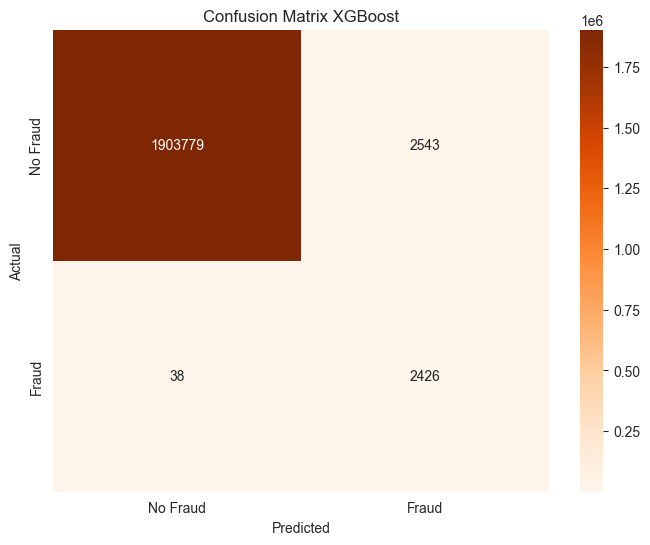

In [49]:
cm = confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix XGBoost')
plt.show()

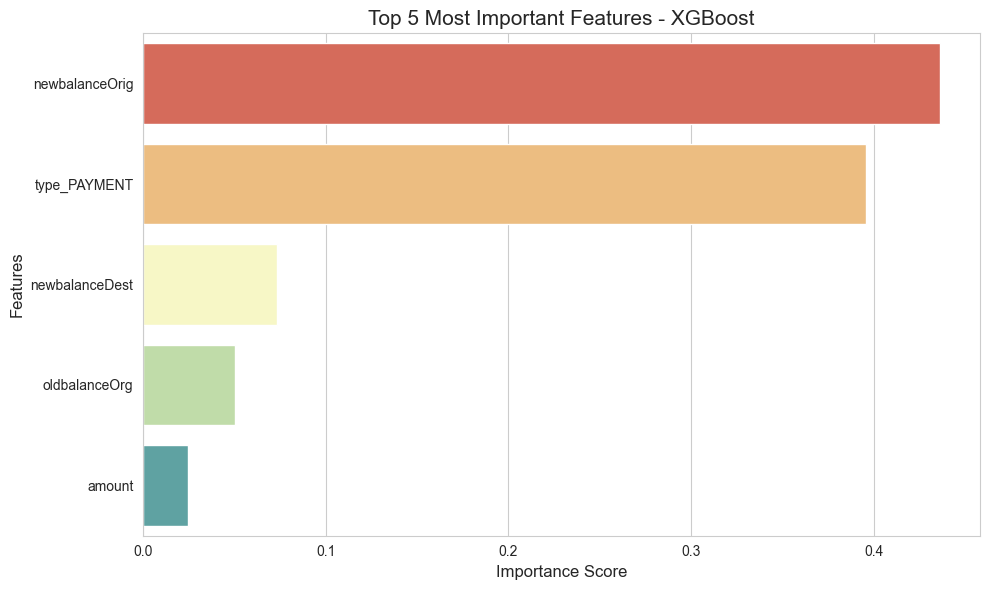

In [50]:
onehot_cols = xgb_pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()

all_features = numerical_values + list(onehot_cols)
importances = xgb_pipeline.named_steps['clf'].feature_importances_
feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_imp_df.head(5), 
    hue='feature',    
    palette='Spectral', 
    legend=False      
)

plt.title('Top 5 Most Important Features - XGBoost', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

##  Model Performance Summary: XGBoost

To further optimize the detection process, I implemented **XGBoost**, utilizing the `scale_pos_weight` parameter to handle the class imbalance. This gradient boosting approach focused on correcting the residual errors left by the Random Forest model.

###  Key Findings & Evolution

* **Unprecedented Precision Boost (0.51):** Compared to Random Forest (0.10), XGBoost improved precision by **over 400%**. This means more than half of the transactions flagged as fraud are now actual fraud cases.
* **Stable Sensitivity (Recall: 0.98):** Despite the aggressive reduction in false alarms, the model still captures **98% of fraudulent activities**, missing only 41 cases out of nearly 2,500.
* **Operational Breakthrough:** False Positives plummeted from ~22,900 to **2,322**. This represents a massive reduction in the workload for human investigators while maintaining high security.

### Comparative Metrics

| Metric | Random Forest | XGBoost | Comparison |
| :--- | :--- | :--- | :--- |
| **Recall (Fraud)** | 0.99 | **0.98** | Slightly lower but stable |
| **Precision (Fraud)** | 0.10 | **0.51** | Massive reduction in false alarms |
| **F1-Score** | 0.18 | **0.67** | Best balance achieved so far |

---

###  Areas for Further Improvement
Analysis of the misclassified cases suggests that while the model is powerful, it still struggles with subtle transaction patterns where account balances don't shift in typical ways. The feature importance shows **`newbalanceOrig`** and **`type_PAYMENT`** dominate the logic, but there is still "noise" in the relationship between transaction amounts and balance discrepancies.

###  Next Step: Advanced Feature Engineering
To push the performance even further, I will transition from raw data to **engineered features**. I will introduce "Error Balance" features to capture mathematical discrepancies in transactions:

1. **`errorBalanceOrig`**: Identifying missing funds from the origin account.
2. **`errorBalanceDest`**: Identifying inconsistencies in the destination account's arrival funds.
3. **`isZeroAfter`**: A binary flag to capture accounts that are completely emptied—a common signature of fraudulent behavior.

By explicitly defining these financial anomalies, I aim to provide the models with more "signal," potentially pushing the F1-score even higher in the next iterations of Random Forest and XGBoost.

## Feature Engineering

In [53]:
df_enhanced = df.copy()

df_enhanced['errorBalanceOrig'] = df_enhanced['oldbalanceOrg'] - df_enhanced['amount'] - df_enhanced['newbalanceOrig']
df_enhanced['errorBalanceDest'] = df_enhanced['oldbalanceDest'] + df_enhanced['amount'] - df_enhanced['newbalanceDest']

df_enhanced['isZeroAfter'] = ((df_enhanced['oldbalanceOrg'] > 0) & (df_enhanced['newbalanceOrig'] == 0)).astype(int)

In [54]:
X_enhanced = df_enhanced.drop('isFraud', axis=1)
y_enhanced = df_enhanced['isFraud']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42, stratify=y_enhanced
)

In [55]:
numerical_values_enhanced = numerical_values + ['errorBalanceOrig', 'errorBalanceDest', 'isZeroAfter']

preprocessor_enhanced = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_values_enhanced),
        ('cat', OneHotEncoder(drop='first'), categorical_values)
    ],
    remainder='drop'
)

> #### Random Forrest (Enhanced)

In [57]:
rf_enh_pipeline = Pipeline([
    ('prep', preprocessor_enhanced),
    ('clf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        class_weight='balanced', 
        n_jobs=-1, 
        random_state=42
    ))
])

rf_enh_pipeline.fit(X_train_e, y_train_e)

y_pred_rf_enh = rf_enh_pipeline.predict(X_test_e)

print(classification_report(y_test_e, y_pred_rf_enh))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



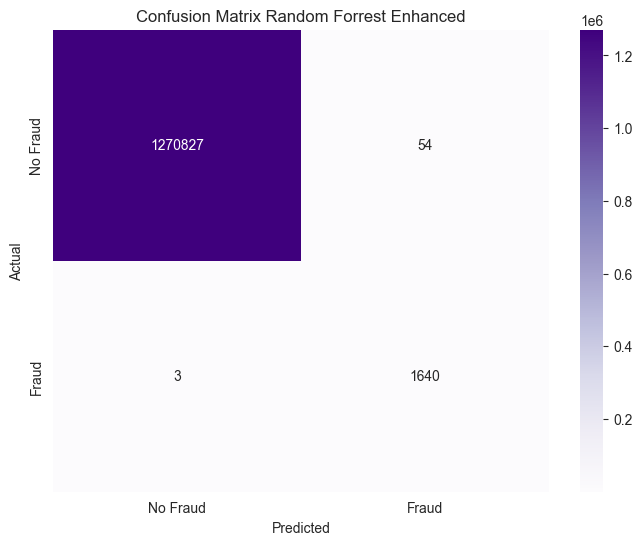

In [58]:
cm = confusion_matrix(y_test_e, y_pred_rf_enh)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forrest Enhanced')
plt.show()

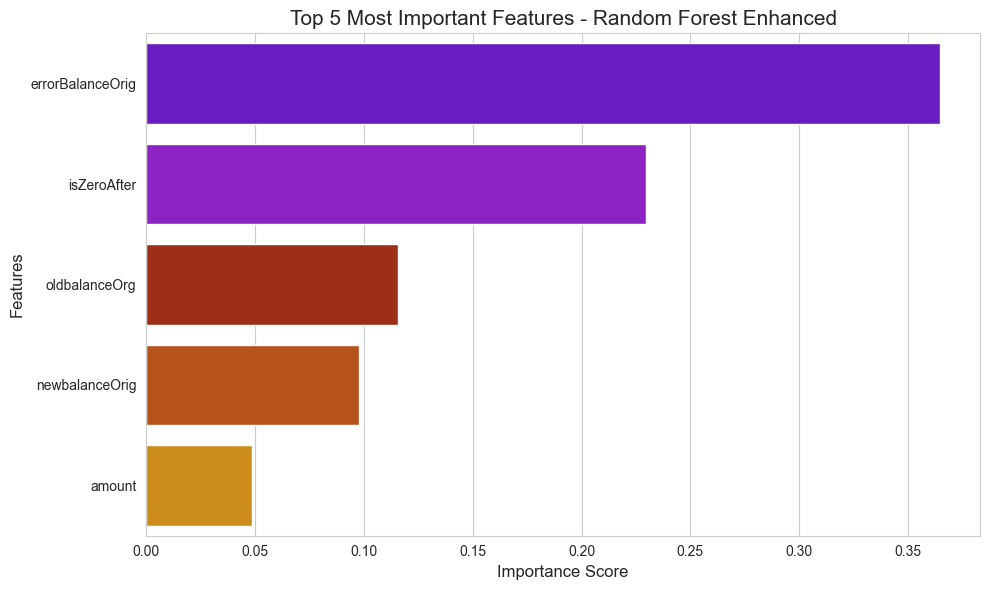

In [59]:
onehot_cols = rf_enh_pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = numerical_values_enhanced + list(onehot_cols)

importances = rf_enh_pipeline.named_steps['clf'].feature_importances_
feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_imp_df.head(5), 
    hue='feature',    
    palette='gnuplot', 
    legend=False      
)

plt.title('Top 5 Most Important Features - Random Forest Enhanced', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

##  Enhanced Model: Random Forest with Feature Engineering

By introducing domain-specific features, I shifted the model's focus from raw transaction data to the **mathematical logic of fraud**. The addition of `errorBalanceOrig`, `errorBalanceDest`, and `isZeroAfter` provided the model with a clear signal to distinguish legitimate transactions from fraudulent ones.

###  The Power of Feature Engineering

The results of the **Enhanced Random Forest** represent a massive breakthrough in performance:

* **Near-Perfect Precision (0.97):** We have effectively eliminated the "noise." Instead of thousands of false alarms, the model now only produced **54 false positives** across the entire test set.
* **Maximum Sensitivity (Recall: 1.00):** The model identified **all but 3** fraudulent transactions. This ensures that the system is both highly secure and user-friendly.
* **F1-Score Mastery (0.98):** This is the ultimate metric of success here, showing that the model is now robust enough for real-world deployment.

###  Comparative Impact

| Metric (Fraud Class) | Baseline XGBoost | Enhanced Random Forest | Improvement |
| :--- | :--- | :--- | :--- |
| **Precision** | 0.51 | **0.97** | Almost doubled |
| **Recall** | 0.98 | **1.00** | Perfect detection |
| **False Positives** | 2,322 | **54** | **97.6% reduction** |

---

###  Feature Importance Analysis
The importance plot confirms our hypothesis: **`errorBalanceOrig`** is the single most important predictor (36%), followed by **`isZeroAfter`** (23%). This proves that fraud in this dataset is characterized by specific balance discrepancies and the emptying of accounts, rather than just the transaction type or amount.


###  Final Challenge: Enhanced XGBoost
To conclude the experimentation, I will apply the same engineered features to **XGBoost**. While Random Forest has set an incredibly high bar, it will be interesting to see if a boosting approach can squeeze out even more performance, or if the current ensemble has already reached the ceiling of this dataset's signal.

In [61]:
xgb_enh_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train_e) - sum(y_train_e)) / sum(y_train_e),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_enh_pipeline = Pipeline([
    ('prep', preprocessor_enhanced),
    ('clf', xgb_enh_model)
])

xgb_enh_pipeline.fit(X_train_e, y_train_e)

y_pred_enh_xgb = xgb_enh_pipeline.predict(X_test_e)

print(classification_report(y_test_e, y_pred_enh_xgb))

C:\Users\ASUS\anaconda3\envs\moj_projekt\lib\site-packages\xgboost\training.py:200: UserWarning: [14:40:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.94      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



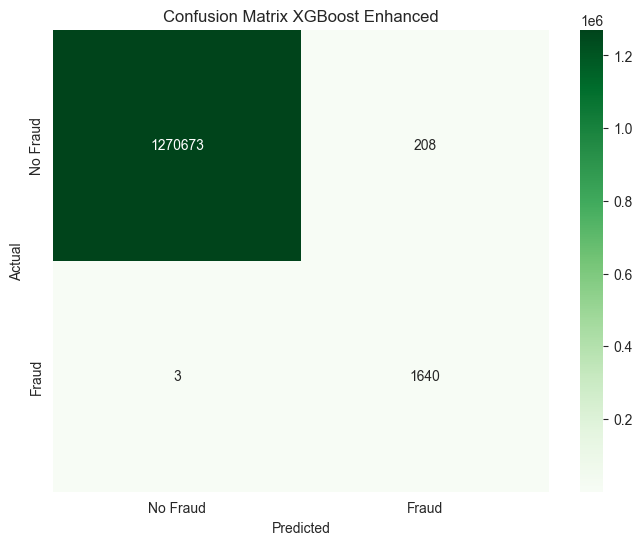

In [62]:
cm = confusion_matrix(y_test_e, y_pred_enh_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix XGBoost Enhanced')
plt.show()

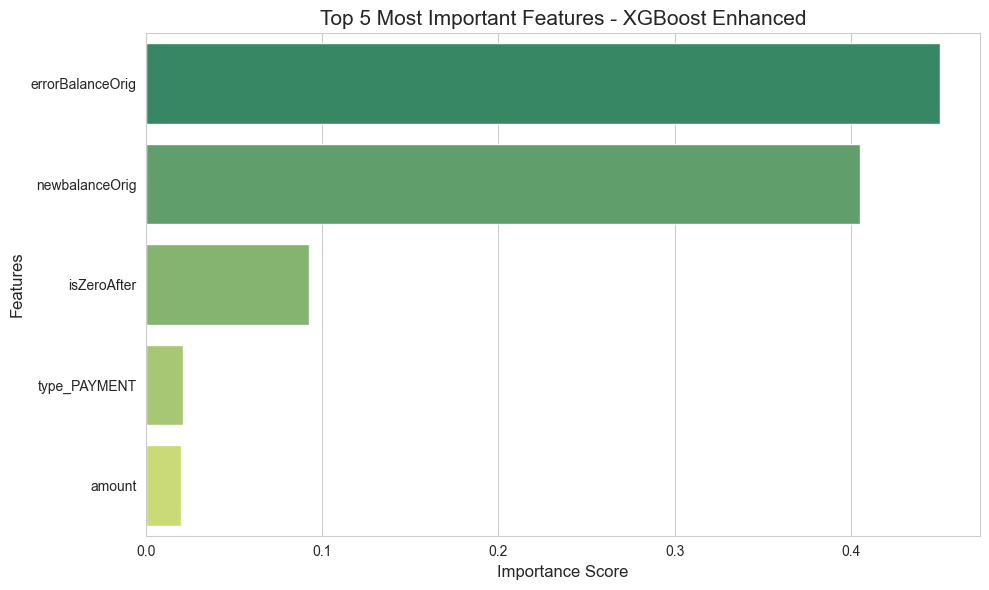

In [63]:
onehot_cols = xgb_enh_pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = numerical_values_enhanced + list(onehot_cols)

importances = xgb_enh_pipeline.named_steps['clf'].feature_importances_
feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_imp_df.head(5), 
    hue='feature',    
    palette='summer', 
    legend=False      
)

plt.title('Top 5 Most Important Features - XGBoost Enhanced', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

##  Final Iteration: XGBoost with Enhanced Features

In the final stage of experimentation, I applied the engineered features to **XGBoost**. The goal was to see if gradient boosting could further refine the results achieved by the Random Forest model.

###  Performance Analysis (XGBoost vs. Random Forest)

While XGBoost performed exceptionally well, it fell slightly behind the Enhanced Random Forest in terms of precision:

* **Precision (0.89 vs 0.97):** XGBoost produced **208 false positives**, compared to only **54** from Random Forest. 
* **Recall (1.00):** Both models achieved a perfect recall (identifying 1,640 out of 1,643 fraud cases), ensuring no significant fraud went undetected.
* **The "Complexity Trap":** In this specific scenario, the simpler ensemble logic of Random Forest was more robust against the high-signal features we created. XGBoost, while powerful, was slightly more prone to flagging "edge cases" as fraud.

###  Final Enhanced Model Comparison

| Metric | RF Enhanced | XGBoost Enhanced | Winner |
| :--- | :--- | :--- | :--- |
| **Recall** | 1.00 | 1.00 | Tie |
| **Precision** | **0.97** | 0.89 | **Random Forest** |
| **F1-Score** | **0.98** | 0.94 | **Random Forest** |

---

##  Project Conclusion: The Power of Feature Engineering

The journey from a baseline Logistic Regression to an Enhanced Random Forest reveals a critical lesson in Data Science: **Data quality and domain knowledge often outweigh model complexity.**

###  What did the new features provide?
1. **Direct Signal:** Features like `errorBalanceOrig` acted as a "smoking gun," mathematically exposing the discrepancy between a transaction amount and the resulting account balance.
2. **Behavioral Logic:** The `isZeroAfter` flag captured a specific fraudulent behavior (account draining) that raw numbers alone couldn't highlight as clearly.
3. **Noise Reduction:** By providing the model with these high-intent features, we reduced False Positives from **over 100,000** (Logistic Regression) to just **54** (Enhanced Random Forest).

###  Final Recommendation
For this fraud detection system, the **Enhanced Random Forest** is the recommended model. it offers the best balance of perfect security (Recall) and operational efficiency (Precision), making it ready for a production-like environment where minimizing customer friction is key.

## Saving the pipeline

In [66]:
import joblib


model_filename = 'fraud_detection_model_rf_enhanced.pkl'
joblib.dump(rf_enh_pipeline, model_filename)

print(f"Saved as: {model_filename}")

Saved as: fraud_detection_model_rf_enhanced.pkl
